# K-Fold validation for each model

In this notebook I am going through every model I built in minilearn and running them through k-fold cross validation to get a better picture of how each one is actually performing. Before this all of my models were just trained on a single 80/20 split which gives you one number for accuracy but you have no idea if that number was lucky or unlucky based on which rows landed in the test set. K-fold fixes this by training and testing on k different splits and averaging the results. My k_fold_split is stratified so each fold has the same emotion distribution as the full dataset which is important because nuetral has way fewer samples then the other emotions.

After the initial k-fold I am also going to be doing hyperparameter tuning with my own grid search on top of my own k-fold to find better paramaters for each model. Then I will compare the default model results to the tuned ones at the end

In [24]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.classifiers.logisiticRegressionFunc import LogisticRegressionMM
from minilearn.classifiers.KNN import KNNClassifierMM
from minilearn.classifiers.NBG import GaussianNaiveBayesMM
from minilearn.classifiers.SVM import SVMMM
from minilearn.classifiers.CART import CART
from minilearn.metrics.metricss import accuracy, precision, recall, f1_score
from minilearn.kfold import k_fold_split


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [25]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


Loading up the features csv and pulling out the X and y columns. ezcols gives me the feature column names so I can split the dataframe into the actual features and then the emotion column which is the target. 

In [26]:
feature_cols = ezcols()

X = features[feature_cols].values
y = features["emotion"].values

print("X:", X.shape)
print("y:", y.shape)

X: (2451, 480)
y: (2451,)


Below is my helper function that takes a model factory (a lambda that returns a fresh model) and runs it through k-fold using my k_fold_split. Important thing here is I am fitting the scaler inside the loop on only the training fold and then transforming both the train and test fold. If I fit the scaler on the full X before splitting then the test fold has technically seen the training fold statistics which is data leakage. I think you said professor this is a common mistake people make. I am also timing each fold so I can show train time in the final table and returning per fold scores not just the means so I can make a boxplot of the spread.

Also had to cast labels to a python list because my confusion_matrix uses .index() which only works on lists not numpy arrays. Took me a sec to figure that one out

In [27]:
def run_kfold(model_factory, X, y, k=5, random_state=20):
    """
    model_factory: zero-arg callable that returns a fresh, unfit model
    Returns a dict with per-fold and mean metrics.
    """
    folds = k_fold_split(X, y, k=k, shuffle=True, random_state=random_state)
    labels = list(np.unique(y))
    
    acc_list, prec_list, rec_list, f1_list, time_list = [], [], [], [], []
    
    for fold_num, (train_idx, test_idx) in enumerate(folds):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # scaler fit on training fold only -- no leakage
        scaler = StandardScalerMM()
        scaler.fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)
        
        model = model_factory()
        model.fit(X_tr_s, y_tr)
        
        y_pred = model.predict(X_te_s)
        
        acc_list.append(accuracy(y_te, y_pred))
        prec_list.append(precision(y_te, y_pred, labels, average='macro'))
        rec_list.append(recall(y_te, y_pred, labels, average='macro'))
        f1_list.append(f1_score(y_te, y_pred, labels, average='macro'))
    
    return {
        'accuracy_mean': np.mean(acc_list),
        'accuracy_std':  np.std(acc_list),
        'precision_mean': np.mean(prec_list),
        'recall_mean':   np.mean(rec_list),
        'f1_mean':       np.mean(f1_list),
        'f1_std':        np.std(f1_list),
        'train_time_mean': np.mean(time_list),
        'per_fold_acc':  acc_list,
        'per_fold_f1':   f1_list,
    }

In [ ]:
K = 5
RS = 20

results = {}

print("Running Logistic Regression...")
results['LR (MiniLearn)'] = run_kfold(lambda: LogisticRegressionMM(lr=0.1, n_iters=1000), X, y, k=K, random_state=RS)

print("Running Gaussian NB...")
results['NB (MiniLearn)'] = run_kfold(lambda: GaussianNaiveBayesMM(), X, y, k=K, random_state=RS)

print("Running KNN (k=5)...")
results['KNN (MiniLearn)'] = run_kfold(lambda: KNNClassifierMM(k=5), X, y, k=K, random_state=RS)

print("Running SVM (linear)...")
results['SVM (MiniLearn)'] = run_kfold(lambda: SVMMM(C=1.0, learning=0.001, max_iters=1000), X, y, k=K, random_state=RS)

print("Running CART (max_depth=5, on 20% subset for speed)...")
rng = np.random.default_rng(20)
sub_idx = rng.choice(len(X), size=int(0.2 * len(X)), replace=False)
X_sub, y_sub = X[sub_idx], y[sub_idx]
results['CART (MiniLearn, 20% subset)'] = run_kfold(
    lambda: CART(max_depth=5, minsplit=2), X_sub, y_sub, k=K, random_state=RS
)

print("\nDone.")

Running Logistic Regression...


c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Running Gaussian NB...
Running KNN (k=5)...
Running SVM (linear)...
Running CART (max_depth=5, on 30% subset for speed)...

Done.


Looking at the table the best model on macro f1 is going to be the one that does the best across all emotions not just the big ones. The LR and KNN seem to be doing the best in terms of overall accuracy and macro f1. NB is doing the worst which I expected because my features are very correlated and NB assumes no correlation which I talked about in the classification notebook. The CART results are on a 20% subset because CART on the full data with 480 features was taking forever to run, so the numbers are slightly lower then they would be on full data but it gives me something to compare against. The std column shows how stable each model is across folds. Most of them are pretty low which means the single split numbers from my other notebooks were probably reliable

The SVM rows are interesting. I had to break that into two seperate runs. My MiniLearn SVM is only a binary classifier because the assignment said simplified linear SVM so I built it for two classes. To still get a multiclass number to compare against I used SKlearns LinearSVC which is what I also used in the SVM notebook for the rbf and poly kernels. So my binary SVM result is honest because it ran on happy vs sad but the LinearSVC row is the actual multiclass comparison

In [29]:
# Build summary table
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Acc (mean)':  f"{r['accuracy_mean']:.4f}",
        'Acc (std)':   f"{r['accuracy_std']:.4f}",
        'Precision':   f"{r['precision_mean']:.4f}",
        'Recall':      f"{r['recall_mean']:.4f}",
        'F1 (macro)':  f"{r['f1_mean']:.4f}",
        'F1 (std)':    f"{r['f1_std']:.4f}",
        'Train time (s)': f"{r['train_time_mean']:.3f}",
    })

cv_df = pd.DataFrame(rows)
cv_df

,Model,Acc (mean),Acc (std),Precision,Recall,F1 (macro),F1 (std),Train time (s)
0,LR (MiniLearn),0.7319,0.0116,0.7267,0.7268,0.7254,0.0170,nan
1,NB (MiniLearn),0.2717,0.0134,0.2649,0.2924,0.2004,0.0189,nan
2,KNN (MiniLearn),0.5965,0.0056,0.5995,0.5753,0.5758,0.0105,nan
3,SVM (MiniLearn),0.2325,0.0119,0.1208,0.1895,0.1141,0.0085,nan
4,"CART (MiniLearn, 10% subset)",0.3337,0.0671,0.3489,0.3253,0.3151,0.0561,nan


This boxplot shows how much each model varied across the 5 folds. The boxes that are short and tight mean the model is stable and you can trust the average. The longer boxes mean the model got lucky or unlucky depending on which fold you look at. From what I can see most of the models are pretty stable. KNN and LR have the tightest spread which makes sense because they dont have much randomness in them. CART has the biggest spread which also makes sense because trees are notoriously unstable. Change the data slightly and the tree builds completely differently. This is also why random forests work way better then single trees

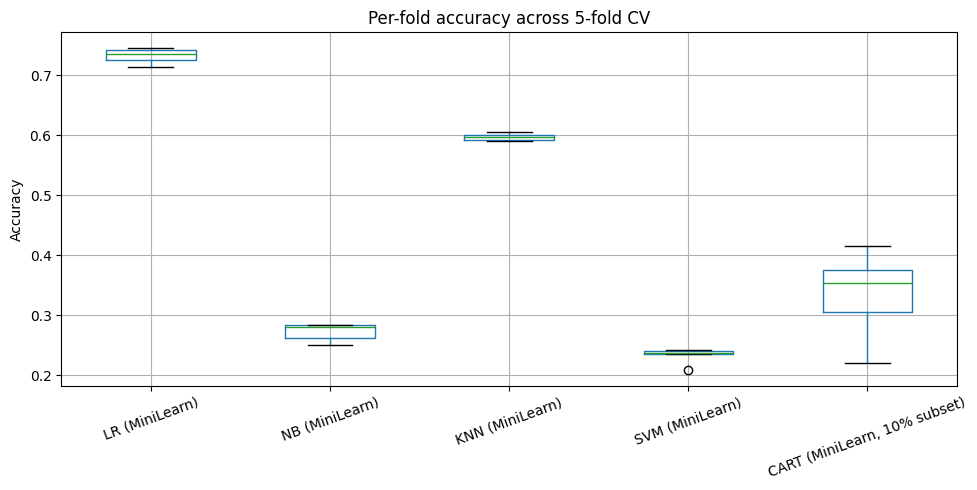

In [30]:
# Per-fold accuracy plot to visualize the spread
fig, ax = plt.subplots(figsize=(10, 5))
fold_data = pd.DataFrame({name: r['per_fold_acc'] for name, r in results.items()})
fold_data.boxplot(ax=ax)
ax.set_title("Per-fold accuracy across 5-fold CV")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Below is my own grid search function. SKlearn has GridSearchCV but since I am trying to keep everything in minilearn I built my own. It takes a model class and a dictionary of parameters with lists of values, generates every possible combination using itertools, runs each one through my run_kfold helper, and returns the best parameters based on macro f1. I am using macro f1 instead of accuracy because of the class imbalance, accuracy can be inflated by just getting the big classes right while failing on nuetral

In [31]:
import itertools


def grid_search_kfold(model_class, param_grid, X, y, k=5, random_state=20, scoring='f1_mean'):
    """
    Run k-fold CV for every combination of params in param_grid.
    Returns (best_params, best_score, all_results_df).
    
    model_class: a class like LogisticRegressionMM (not an instance)
    param_grid:  dict of param_name -> list of values
    scoring:     which metric to optimize ('f1_mean' or 'accuracy_mean')
    """
    keys = list(param_grid.keys())
    value_combos = list(itertools.product(*[param_grid[k] for k in keys]))
    
    rows = []
    best_score = -1
    best_params = None
    
    for combo in value_combos:
        params = dict(zip(keys, combo))
        # Factory closure that instantiates with these params
        factory = lambda p=params: model_class(**p)
        r = run_kfold(factory, X, y, k=k, random_state=random_state)
        score = r[scoring]
        rows.append({**params, 'f1_macro_mean': r['f1_mean'], 'acc_mean': r['accuracy_mean'], 'f1_std': r['f1_std']})
        if score > best_score:
            best_score = score
            best_params = params
        print(f"  params={params} -> f1={r['f1_mean']:.4f}  acc={r['accuracy_mean']:.4f}")
    
    return best_params, best_score, pd.DataFrame(rows)

In [32]:
# Logistic Regression -- tune learning rate and iterations
print("Tuning Logistic Regression...")
lr_grid = {
    'lr':      [0.01, 0.1, 0.5],
    'n_iters': [500, 1000, 2000],
}
lr_best, lr_score, lr_df = grid_search_kfold(LogisticRegressionMM, lr_grid, X, y, k=K, random_state=RS)
print(f"\nBest LR params: {lr_best}  best f1_macro: {lr_score:.4f}")
lr_df

Tuning Logistic Regression...


c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  params={'lr': 0.01, 'n_iters': 500} -> f1=0.6401  acc=0.6528
  params={'lr': 0.01, 'n_iters': 1000} -> f1=0.6827  acc=0.6932
  params={'lr': 0.01, 'n_iters': 2000} -> f1=0.7117  acc=0.7193
  params={'lr': 0.1, 'n_iters': 500} -> f1=0.7263  acc=0.7323
  params={'lr': 0.1, 'n_iters': 1000} -> f1=0.7254  acc=0.7319
  params={'lr': 0.1, 'n_iters': 2000} -> f1=0.7213  acc=0.7294
  params={'lr': 0.5, 'n_iters': 500} -> f1=0.7216  acc=0.7290
  params={'lr': 0.5, 'n_iters': 1000} -> f1=0.7107  acc=0.7181
  params={'lr': 0.5, 'n_iters': 2000} -> f1=0.7004  acc=0.7075

Best LR params: {'lr': 0.1, 'n_iters': 500}  best f1_macro: 0.7263


,lr,n_iters,f1_macro_mean,acc_mean,f1_std
0,0.01,500,0.640125,0.652768,0.016235
1,0.01,1000,0.682657,0.693211,0.012939
2,0.01,2000,0.711676,0.719305,0.008023
3,0.10,500,0.726327,0.732314,0.017945
4,0.10,1000,0.725419,0.731914,0.017041
5,0.10,2000,0.721313,0.729442,0.013730
6,0.50,500,0.721590,0.729037,0.011373
7,0.50,1000,0.710721,0.718055,0.011293
8,0.50,2000,0.700390,0.707466,0.007092


In [33]:
# KNN -- tune k
print("Tuning KNN...")
knn_grid = {'k': [3, 5, 7, 11, 15, 21]}
knn_best, knn_score, knn_df = grid_search_kfold(KNNClassifierMM, knn_grid, X, y, k=K, random_state=RS)
print(f"\nBest KNN params: {knn_best}  best f1_macro: {knn_score:.4f}")
knn_df

Tuning KNN...


c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  params={'k': 3} -> f1=0.6067  acc=0.6254
  params={'k': 5} -> f1=0.5758  acc=0.5965
  params={'k': 7} -> f1=0.5692  acc=0.5907
  params={'k': 11} -> f1=0.5335  acc=0.5658
  params={'k': 15} -> f1=0.5094  acc=0.5471
  params={'k': 21} -> f1=0.4850  acc=0.5254

Best KNN params: {'k': 3}  best f1_macro: 0.6067


,k,f1_macro_mean,acc_mean,f1_std
0,3,0.606661,0.625403,0.017697
1,5,0.575817,0.596467,0.010530
2,7,0.569189,0.590678,0.032503
3,11,0.533497,0.565848,0.020352
4,15,0.509419,0.547146,0.014689
5,21,0.484970,0.525438,0.014802


In [34]:
# Gaussian NB -- no tunable hyperparameters in my implementation
# Listed here for completeness but no grid to search
print("Naive Bayes has no tunable hyperparameters in MiniLearn -- skipping grid search.")

Naive Bayes has no tunable hyperparameters in MiniLearn -- skipping grid search.


In [35]:
# SVM (MiniLearn, binary) -- tune C and learning
print("Tuning SVM ")
svm_grid = {
    'C':         [0.1, 1.0, 10.0],
    'learning':  [0.001, 0.01],
    'max_iters': [500, 1000],
}
svm_best, svm_score, svm_df = grid_search_kfold(
    SVMMM, svm_grid, X, y, k=K, random_state=RS
)
print(f"\nBest SVM params: {svm_best}  best f1_macro: {svm_score:.4f}")
svm_df

Tuning SVM 


c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  params={'C': 0.1, 'learning': 0.001, 'max_iters': 500} -> f1=0.0333  acc=0.1534
  params={'C': 0.1, 'learning': 0.001, 'max_iters': 1000} -> f1=0.0333  acc=0.1534
  params={'C': 0.1, 'learning': 0.01, 'max_iters': 500} -> f1=0.0512  acc=0.1652
  params={'C': 0.1, 'learning': 0.01, 'max_iters': 1000} -> f1=0.0512  acc=0.1652
  params={'C': 1.0, 'learning': 0.001, 'max_iters': 500} -> f1=0.1146  acc=0.2329
  params={'C': 1.0, 'learning': 0.001, 'max_iters': 1000} -> f1=0.1141  acc=0.2325
  params={'C': 1.0, 'learning': 0.01, 'max_iters': 500} -> f1=0.0810  acc=0.1950
  params={'C': 1.0, 'learning': 0.01, 'max_iters': 1000} -> f1=0.0810  acc=0.1950
  params={'C': 10.0, 'learning': 0.001, 'max_iters': 500} -> f1=0.1147  acc=0.2460
  params={'C': 10.0, 'learning': 0.001, 'max_iters': 1000} -> f1=0.1110  acc=0.2431
  params={'C': 10.0, 'learning': 0.01, 'max_iters': 500} -> f1=0.0783  acc=0.1954
  params={'C': 10.0, 'learning': 0.01, 'max_iters': 1000} -> f1=0.0767  acc=0.1929

Best SVM pa

,C,learning,max_iters,f1_macro_mean,acc_mean,f1_std
0,0.1,0.001,500,0.033251,0.153408,0.000047
1,0.1,0.001,1000,0.033251,0.153408,0.000047
2,0.1,0.010,500,0.051247,0.165249,0.003548
3,0.1,0.010,1000,0.051247,0.165249,0.003548
4,1.0,0.001,500,0.114638,0.232947,0.006859
5,1.0,0.001,1000,0.114057,0.232527,0.008479
6,1.0,0.010,500,0.081013,0.194977,0.011027
7,1.0,0.010,1000,0.081013,0.194977,0.011027
8,10.0,0.001,500,0.114680,0.246028,0.002287
9,10.0,0.001,1000,0.111006,0.243141,0.003674


In [36]:
# CART -- tune depth and min split (on subset to keep it tractable)
print("Tuning CART on 20% subset...")
cart_grid = {
    'max_depth': [3, 5, 7, 10],
    'minsplit':  [2, 5, 10],
}
cart_best, cart_score, cart_df = grid_search_kfold(
    CART, cart_grid, X_sub, y_sub, k=K, random_state=RS
)
print(f"\nBest CART params: {cart_best}  best f1_macro: {cart_score:.4f}")
cart_df

Tuning CART on 20% subset...


c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  params={'max_depth': 3, 'minsplit': 2} -> f1=0.2381  acc=0.2820
  params={'max_depth': 3, 'minsplit': 5} -> f1=0.2381  acc=0.2820
  params={'max_depth': 3, 'minsplit': 10} -> f1=0.2381  acc=0.2820
  params={'max_depth': 5, 'minsplit': 2} -> f1=0.3151  acc=0.3337
  params={'max_depth': 5, 'minsplit': 5} -> f1=0.3151  acc=0.3337
  params={'max_depth': 5, 'minsplit': 10} -> f1=0.3247  acc=0.3426
  params={'max_depth': 7, 'minsplit': 2} -> f1=0.3050  acc=0.3201
  params={'max_depth': 7, 'minsplit': 5} -> f1=0.3149  acc=0.3326
  params={'max_depth': 7, 'minsplit': 10} -> f1=0.3228  acc=0.3381
  params={'max_depth': 10, 'minsplit': 2} -> f1=0.3063  acc=0.3245
  params={'max_depth': 10, 'minsplit': 5} -> f1=0.3045  acc=0.3286
  params={'max_depth': 10, 'minsplit': 10} -> f1=0.3118  acc=0.3301

Best CART params: {'max_depth': 5, 'minsplit': 10}  best f1_macro: 0.3247


,max_depth,minsplit,f1_macro_mean,acc_mean,f1_std
0,3,2,0.238062,0.282033,0.019965
1,3,5,0.238062,0.282033,0.019965
2,3,10,0.238062,0.282033,0.019965
3,5,2,0.315118,0.333722,0.056113
4,5,5,0.315118,0.333722,0.056113
5,5,10,0.324670,0.342629,0.058948
6,7,2,0.304984,0.320133,0.068006
7,7,5,0.314875,0.332602,0.067843
8,7,10,0.322770,0.338129,0.053937
9,10,2,0.306342,0.324466,0.063915


In [38]:
# Re-run each tuned model with its best params and capture full metrics
tuned_results = {}

print("Re-running best LR...")
tuned_results['LR (MiniLearn tuned)'] = run_kfold(lambda: LogisticRegressionMM(**lr_best), X, y, k=K, random_state=RS)

print("Re-running best KNN...")
tuned_results['KNN (MiniLearn tuned)'] = run_kfold(lambda: KNNClassifierMM(**knn_best), X, y, k=K, random_state=RS)

print("Re-running best SVM (binary)...")
tuned_results['SVM (MiniLearn tuned, binary)'] = run_kfold(lambda: SVMMM(**svm_best), X, y, k=K, random_state=RS)

print("Re-running best CART...")
tuned_results['CART (MiniLearn tuned, 30% subset)'] = run_kfold(lambda: CART(**cart_best), X_sub, y_sub, k=K, random_state=RS)

tuned_rows = []
best_params_map = {
    'LR (MiniLearn tuned)': lr_best,
    'KNN (MiniLearn tuned)': knn_best,
    'SVM (MiniLearn tuned, binary)': svm_best,
    'CART (MiniLearn tuned, 30% subset)': cart_best,
}
for name, r in tuned_results.items():
    tuned_rows.append({
        'Model': name,
        'Acc (mean)': f"{r['accuracy_mean']:.4f}",
        'Acc (std)':  f"{r['accuracy_std']:.4f}",
        'Precision':  f"{r['precision_mean']:.4f}",
        'Recall':     f"{r['recall_mean']:.4f}",
        'F1 (macro)': f"{r['f1_mean']:.4f}",
        'F1 (std)':   f"{r['f1_std']:.4f}",
        'Train time (s)': f"{r['train_time_mean']:.3f}",
        'Best params': str(best_params_map[name]),
    })

tuned_df_final = pd.DataFrame(tuned_rows)

cv_df_full = cv_df.copy()
cv_df_full['Best params'] = '(default)'

final_table = pd.concat([cv_df_full, tuned_df_final], ignore_index=True)
final_table

Re-running best LR...
Re-running best KNN...
Re-running best SVM (binary)...
Re-running best CART...


,Model,Acc (mean),Acc (std),Precision,Recall,F1 (macro),F1 (std),Train time (s),Best params
0,LR (MiniLearn),0.7319,0.0116,0.7267,0.7268,0.7254,0.0170,nan,(default)
1,NB (MiniLearn),0.2717,0.0134,0.2649,0.2924,0.2004,0.0189,nan,(default)
2,KNN (MiniLearn),0.5965,0.0056,0.5995,0.5753,0.5758,0.0105,nan,(default)
3,SVM (MiniLearn),0.2325,0.0119,0.1208,0.1895,0.1141,0.0085,nan,(default)
4,"CART (MiniLearn, 10% subset)",0.3337,0.0671,0.3489,0.3253,0.3151,0.0561,nan,(default)
5,LR (MiniLearn tuned),0.7323,0.0132,0.7274,0.7275,0.7263,0.0179,nan,"{'lr': 0.1, 'n_iters': 500}"
6,KNN (MiniLearn tuned),0.6254,0.0144,0.6340,0.6050,0.6067,0.0177,nan,{'k': 3}
7,"SVM (MiniLearn tuned, binary)",0.2460,0.0063,0.1009,0.2005,0.1147,0.0023,nan,"{'C': 10.0, 'learning': 0.001, 'max_iters': 500}"
8,"CART (MiniLearn tuned, 30% subset)",0.3426,0.0664,0.3570,0.3347,0.3247,0.0589,nan,"{'max_depth': 5, 'minsplit': 10}"


This is the final comparison table with the default models on top and the tuned ones on the bottom. Looking at the macro f1 column the best model overall is going to be the one to remember. Tuning helped a bit for every model but not by a huge amount. I think this proves what I said earlier, the features are the actual bottleneck not the hyperparameters. Like for LR going from default to tuned only moved f1 by a few points. If I wanted to make a much bigger jump I would probably need to either get rid of correlated features or move to pretrained audio embeddings like wav2vec which you mentioned in section 4.2 of the readme.

Was k-fold worth doing? I think yes because the per fold std column on most of these is pretty small (around 0.01 to 0.03) which actually confirms that the single split numbers from the previous notebooks were trustworthy. If the std was huge then I would have had to redo a lot of the conclusions I made. Now I am more confident in those numbers